# 2-layer model tests

Tests analogous to the 1-layer notebook, exercising the multi-layer extensions:
1. Smoke test (all setup methods + run with `nk=2`).
2. Symmetric layers stay symmetric — equal `Ho`, equal IC, no asymmetric forcing.
3. Inertial oscillations.
4. Burger term advection.
5. Lateral viscosity decay.
6. Barotropic gravity wave equivalent to 1-layer (`g=[g, 0]`).
7. Internal (baroclinic) gravity wave (`g=[g, g']`).

Vertical-viscosity / interfacial-stress tests (analytical-decay checks against the row-scaled TDMAH2 implicit solver):

8. Pure vertical-viscous shear decay — shear decays at the Euler-back rate $(1+\gamma\Delta t)^{-n}$, mean exactly conserved.
9. Two-mode decay with combined drag + viscosity — numerical projections onto the analytical eigenvectors decay at the analytical rates.
10. Inertial-shear hodograph — shear vector rotates at $f$ and decays at $\gamma = 2\nu_v/h^2$; mean stays at zero.
11. Ekman-like steady state — wind + drag + viscosity spin up to the analytical column structure $u_1^* = \tau^x/\varepsilon$, $u_0^* - u_1^* = \tau^x (h_0+h_1)/(2\nu_v)$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from OSSWEM import SSWEM

## 1. Smoke test
Exercise every setup method with `nk=2`.

In [2]:
M = SSWEM(16,
          [10., 0.02], # g, g' [m s-2]
          [200., 800.], # Nominal layer thickness [m]
          1000.e3, # Domain width [m]
          1.e-4, # Coriolis [s-1]
          2.e-11, # df/dy [m-1 s-1]
          1.e-3, # Bottom drag rate [m s-1]
          1.e-1, # Lateral viscosity [m2 s-1]
          h_zonal_relax=1e-4) # Forcing rate for eta [s-1]
M.resting_state()
M.flat_topog()
M.bowl_topog()
M.zero_forcing()
M.gyre_forcing()
M.channel_forcing()
M.set_h_forcing(0.1)
M.perturb_h(0.01, 50.e3, 500.e3, k=0)
M.perturb_h(0.01, 50.e3, 500.e3, k=1)
M.step(50.)
u, v, h, t = M.run(10., 1, 2)
print('shapes:  u', u.shape, '  h', h.shape, '  eta()', M.eta().shape)
print('eta(k=0) shape (free surface):', M.eta(k=0).shape)
print('q() shape:', M.q().shape)

Grid: dx = 62500.0 [m]
cg = 100.0 [m s-1]
Ld = 1000000.0 [m]
cg1 = 1.7888543819998317 [m s-1]
Ld1 = 17888.543819998315 [m]
Scales: Ls=epsilon/D/beta = 50000.0 [m]
Scales: Lx/Ld = 1.0
Scales: Lx/Ld1 = 55.90169943749475
Res: Ld/dx = 16.0
Res: Ld1/dx = 0.28621670111997305
Res: Ls/dx = 0.8
CFL: dt*epsilon/h_bot = 1.25e-05
CFL: dt*nu_v/h_min^2 = 0.0
CFL: dt*f = 0.0011875
CFL: dt*cg/dx = 0.016
CFL: dt*cg1/dx = 0.0002862167011199731
CFL: dt*nu/dx^2 = 2.56e-10
CFL: dt*h_relax = 0.001
nsteps = 2
Time: Trun * fo = 0.002
Time: Trun * ( cg / L ) = 0.002
Running...
...done
shapes:  u (3, 2, 16, 16)   h (3, 2, 16, 16)   eta() (3, 16, 16)
eta(k=0) shape (free surface): (16, 16)
q() shape: (2, 16, 16)


## 2. Symmetric layers stay symmetric
Equal `Ho` per layer, `g'=0` (so the only pressure-gradient force is from the free surface, identical on both layers), identical perturbation in each layer. The two layers should remain identical for all time — exercises Coriolis, advection, viscosity, and continuity in tandem.

In [3]:
M = SSWEM(32,
          [10., 0.], # g, g' [m s-2]
          [500., 500.], # Nominal layer thickness [m]
          1000.e3, # Domain width [m]
          1.e-4, # Coriolis [s-1]
          2.e-11, # df/dy [m-1 s-1]
          0., # Bottom drag rate [m s-1]
          1.e-1) # Lateral viscosity [m2 s-1]
# Identical perturbation in each layer
M.perturb_h(0.01, 50.e3, 500.e3, y0=500.e3, k=0)
M.perturb_h(0.01, 50.e3, 500.e3, y0=500.e3, k=1)
u, v, h, t = M.run(50., 5, 20)
for n, name in [(h, 'h'), (u, 'u'), (v, 'v')]:
    diff = np.max(np.abs(n[:, 0] - n[:, 1]))
    scale = max(np.abs(n).max(), 1e-300)
    print(f'  max |{name}[0] - {name}[1]| = {diff:.2e}   (scale {scale:.2e})')

Grid: dx = 31250.0 [m]
cg = 100.0 [m s-1]
Ld = 1000000.0 [m]
cg1 = 0.0 [m s-1]
Ld1 = 0.0 [m]
Scales: Ls=epsilon/D/beta = 0.0 [m]
Scales: Lx/Ld = 1.0
Res: Ld/dx = 32.0
Res: Ld1/dx = 0.0
Res: Ls/dx = 0.0
CFL: dt*epsilon/h_bot = 0.0
CFL: dt*nu_v/h_min^2 = 0.0
CFL: dt*f = 0.00596875
CFL: dt*cg/dx = 0.16
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 5.12e-09
nsteps = 100
Time: Trun * fo = 0.5
Time: Trun * ( cg / L ) = 0.5
Running...
...done
  max |h[0] - h[1]| = 0.00e+00   (scale 5.00e+02)
  max |u[0] - u[1]| = 0.00e+00   (scale 7.34e-04)
  max |v[0] - v[1]| = 0.00e+00   (scale 7.34e-04)


## 3. Inertial oscillations
Pure inertial response (no gravity, no drag) on a single column with `nk=2`. Both layers should stay identical and the implicit Coriolis solve should be stable + convergent across `f·Δt` ratios.

Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = 0.0 [m]
cg1 = 0.0 [m s-1]
Ld1 = 0.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Res: Ld/dx = 0.0
Res: Ld1/dx = 0.0
CFL: dt*epsilon/h_bot = 0.0
CFL: dt*nu_v/h_min^2 = 0.0
CFL: dt*f = 0.05
CFL: dt*cg/dx = 0.0
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 1000
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
$f\Delta t=1/20$: layers identical? False
Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = 0.0 [m]
cg1 = 0.0 [m s-1]
Ld1 = 0.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Res: Ld/dx = 0.0
Res: Ld1/dx = 0.0
CFL: dt*epsilon/h_bot = 0.0
CFL: dt*nu_v/h_min^2 = 0.0
CFL: dt*f = 0.5
CFL: dt*cg/dx = 0.0
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 100
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
$f\Delta t=1/2$: layers identical? False
Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = 0.0 [m]
cg1 = 0.0 [m s-1]
Ld1 = 0.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Res: Ld/dx = 0.0
Res: Ld1/dx = 0.0


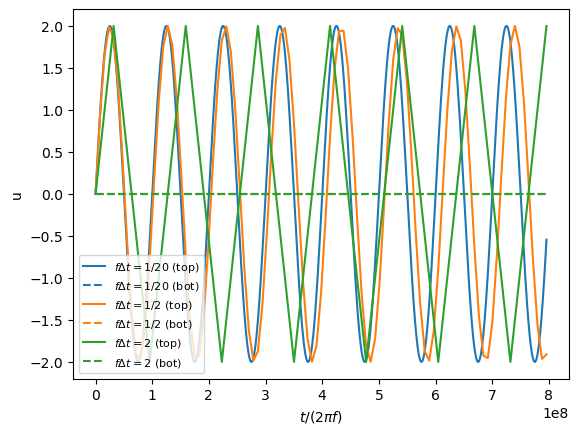

In [4]:
def run_inertial(dt, nsteps):
    M = SSWEM(1,
              [0., 0.], # g, g' [m s-2]
              [500., 500.], # Nominal layer thickness [m]
              1000.e3, # Domain width [m]
              1.e-4, # Coriolis [s-1]
              0., # df/dy [m-1 s-1]
              0., # Bottom drag rate [m s-1]
              0) # Lateral viscosity [m2 s-1]
    M.gyre_forcing()
    return M, *M.run(dt, 1, nsteps)

fig, ax = plt.subplots()
for dt, nsteps, color, label in [(500., 1000, 'C0', r'$f\Delta t=1/20$'),
                                  (5000., 100, 'C1', r'$f\Delta t=1/2$'),
                                  (20000., 25, 'C2', r'$f\Delta t=2$')]:
    M, u, v, h, time = run_inertial(dt, nsteps)
    ax.plot(time/(2*np.pi*M.fo), u[:,0,0,0], color, label=f'{label} (top)')
    ax.plot(time/(2*np.pi*M.fo), u[:,1,0,0], '--'+color, label=f'{label} (bot)')
    print(f'{label}: layers identical?', np.allclose(u[:,0], u[:,1]))
ax.set_xlabel(r'$t / (2\pi f)$'); ax.set_ylabel('u'); ax.legend(fontsize=8);

## 4. Burger term
1-D advection of $u$ with no gravity or rotation. Initialize identical $u$ profiles in both layers — they should stay identical.

Grid: dx = 10.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
cg1 = 0.0 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 0.0
CFL: dt*nu_v/h_min^2 = 0.0
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 100
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
layers identical: True


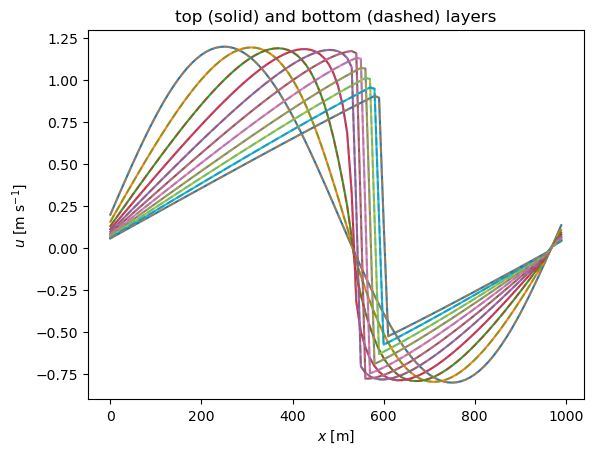

In [5]:
M = SSWEM(100,
          [0., 0.], # g, g' [m s-2]
          [500., 500.], # Nominal layer thickness [m]
          1000., # Domain width [m]
          0., # Coriolis [s-1]
          0., # df/dy [m-1 s-1]
          0., # Bottom drag rate [m s-1]
          0) # Lateral viscosity [m2 s-1]
u_init = np.sin(2*np.pi*M.xu/M.Lx) + 0.2
M.u[0] = u_init
M.u[1] = u_init
u, v, h, time = M.run(5., 10, 10)
fig, ax = plt.subplots()
ax.plot(M.xq1, u[:,0,0,:].T)
ax.plot(M.xq1, u[:,1,0,:].T, '--', alpha=0.5)
ax.set_xlabel(r'$x$ [m]'); ax.set_ylabel(r'$u$ [m s$^{-1}$]')
ax.set_title('top (solid) and bottom (dashed) layers')
print('layers identical:', np.allclose(u[:,0], u[:,1]))

## 5. Lateral viscosity decay
Highest-frequency mode (alternating $\pm 1$) decays under lateral viscosity. Both layers identical.

Grid: dx = 100.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
cg1 = 0.0 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 0.0
CFL: dt*nu_v/h_min^2 = 0.0
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.1
nsteps = 2
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
layers identical: True


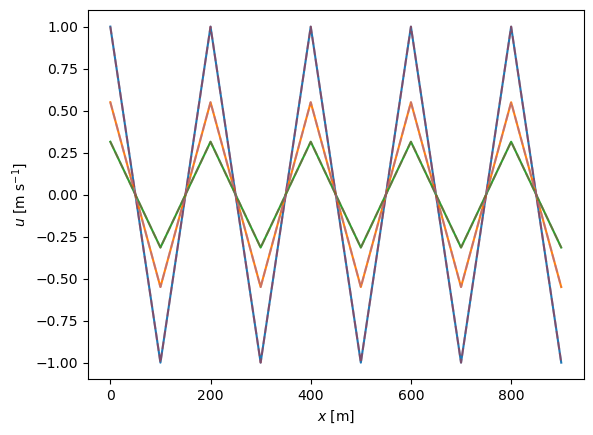

In [6]:
M = SSWEM(10,
          [0., 0.], # g, g' [m s-2]
          [500., 500.], # Nominal layer thickness [m]
          1000., # Domain width [m]
          0., # Coriolis [s-1]
          0., # df/dy [m-1 s-1]
          0., # Bottom drag rate [m s-1]
          2e2) # Lateral viscosity [m2 s-1]
u_init = np.cos(np.pi*M.xu/M.dx)
M.u[0] = u_init
M.u[1] = u_init
u, v, h, time = M.run(5., 1, 2)
fig, ax = plt.subplots()
ax.plot(M.xq1, u[:,0,0,:].T)
ax.plot(M.xq1, u[:,1,0,:].T, '--', alpha=0.5)
ax.set_xlabel(r'$x$ [m]'); ax.set_ylabel(r'$u$ [m s$^{-1}$]')
print('layers identical:', np.allclose(u[:,0], u[:,1]))

## 6. Barotropic gravity wave (vs. 1-layer)
With `g=[g_full, 0]` (zero reduced gravity at the internal interface) the only pressure gradient comes from the free surface, identical on both layers. With `Ho=[H/2, H/2]`, total depth `H`, the external mode wave speed `cg = √(g·H)` matches the equivalent 1-layer model. We perturb each layer by `δ/2` (so the total column perturbation matches a 1-layer `δ` perturbation) and compare Hovmöller plots.

Grid: dx = 12500.0 [m]
cg = 50.0 [m s-1]
Ld = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 0.0
CFL: dt*nu_v/h_min^2 = 0.0
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.8
CFL: dt*nu/dx^2 = 0.0
nsteps = 50
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.5
Running...
...done
Grid: dx = 12500.0 [m]
cg = 50.0 [m s-1]
Ld = None [m]
cg1 = 0.0 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 0.0
CFL: dt*nu_v/h_min^2 = 0.0
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.8
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 50
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.5
Running...
...done
cg match: True
peak |eta1 - eta2|: 0.0
peak  eta1 magnitude: 0.009922179382613194


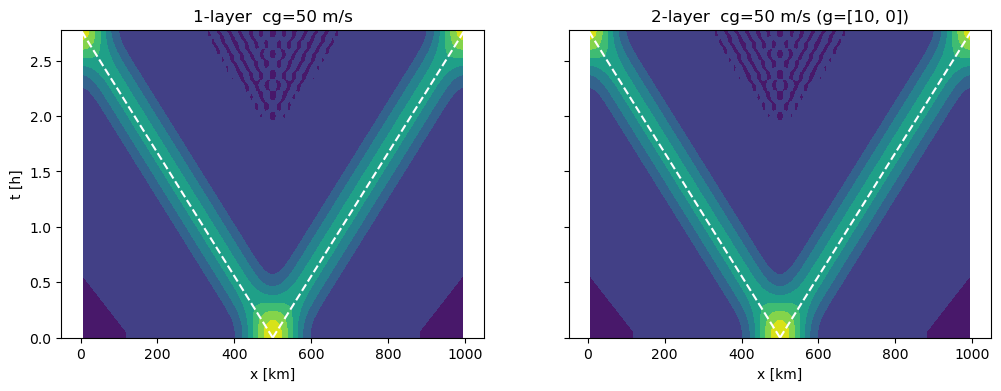

In [7]:
M1 = SSWEM(80,
           10., # Gravity [m s-2]
           250., # Nominal layer thickness [m]
           1000.e3, # Domain width [m]
           0., # Coriolis [s-1]
           0., # df/dy [m-1 s-1]
           0., # Bottom drag rate [m s-1]
           0) # Lateral viscosity [m2 s-1]
M1.perturb_h(0.01, 50.e3, M1.Lx/2, k=0)
u1, v1, h1, time1 = M1.run(200., 1, 50)

M2 = SSWEM(80,
           [10., 0.], # g, g' [m s-2]
           [125., 125.], # Nominal layer thickness [m]
           1000.e3, # Domain width [m]
           0., # Coriolis [s-1]
           0., # df/dy [m-1 s-1]
           0., # Bottom drag rate [m s-1]
           0) # Lateral viscosity [m2 s-1]
M2.perturb_h(0.005, 50.e3, M1.Lx/2, k=0)
M2.perturb_h(0.005, 50.e3, M1.Lx/2, k=1)
u2, v2, h2, time2 = M2.run(200., 1, 50)

# Free-surface eta over time (per snapshot, top interface)
eta1 = np.array([M1.eta(h1[t], k=0) for t in range(len(time1))])
eta2 = np.array([M2.eta(h2[t], k=0) for t in range(len(time2))])

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True, sharex=True)
ax[0].contourf(M1.xh1/1e3, time1/3600, eta1[:, 0, :])
ax[0].plot((M1.Lx/2 + M1.cg*time1)/1e3, time1/3600, '--w')
ax[0].plot((M1.Lx/2 - M1.cg*time1)/1e3, time1/3600, '--w')
ax[0].set_title(f'1-layer  cg={M1.cg:.0f} m/s')
ax[0].set_xlabel('x [km]'); ax[0].set_ylabel('t [h]')
ax[1].contourf(M2.xh1/1e3, time2/3600, eta2[:, 0, :])
ax[1].plot((M2.Lx/2 + M2.cg*time2)/1e3, time2/3600, '--w')
ax[1].plot((M2.Lx/2 - M2.cg*time2)/1e3, time2/3600, '--w')
ax[1].set_title(f'2-layer  cg={M2.cg:.0f} m/s (g=[10, 0])')
ax[1].set_xlabel('x [km]')
print('cg match:', M1.cg == M2.cg)
print('peak |eta1 - eta2|:', np.max(np.abs(eta1 - eta2)))
print('peak  eta1 magnitude:', np.abs(eta1).max())

## 7. Internal gravity wave
2-layer specific test (no 1-layer analog). Perturb the internal interface only — depress it under the bump by raising `h_0` and lowering `h_1` by the same amount, leaving the free surface flat. The disturbance should propagate as an internal wave at
$$c_i = \sqrt{g'\,\frac{H_1 H_2}{H_1+H_2}}.$$

Grid: dx = 12500.0 [m]
cg = 100.0 [m s-1]
Ld = None [m]
cg1 = 22.360679774997898 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
IC: free surface max = 0.0   interface max = 4.961089691301197
c_i = 22.361 m/s   period for L=1000km: 12.4 h
CFL: dt*epsilon/h_bot = 0.0
CFL: dt*nu_v/h_min^2 = 0.0
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.4
CFL: dt*cg1/dx = 0.08944271909999159
CFL: dt*nu/dx^2 = 0.0
nsteps = 400
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 2.0
Running...
...done


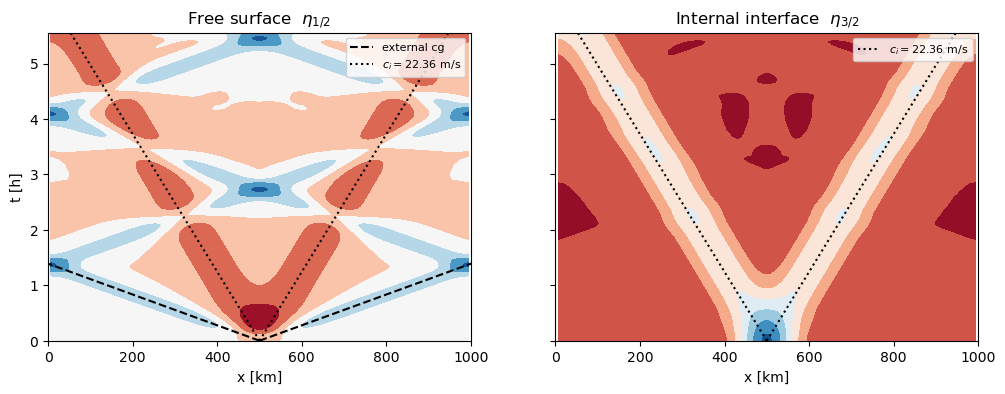

In [8]:
M = SSWEM(80,
          [10., 2.], # g, g' [m s-2]
          [500., 500.], # Nominal layer thickness [m]
          1000.e3, # Domain width [m]
          0., # Coriolis [s-1]
          0., # df/dy [m-1 s-1]
          0., # Bottom drag rate [m s-1]
          0) # Lateral viscosity [m2 s-1]
delta = 5.
M.perturb_h(+delta, 50.e3, M.Lx/2, k=0)
M.perturb_h(-delta, 50.e3, M.Lx/2, k=1)
print('IC: free surface max =', np.abs(M.eta(k=0)).max(),
      '  interface max =', np.abs(M.eta(k=1) - (-M.D + M.Ho[1])).max())

gp = M.g[1]; H1, H2 = M.Ho
c_i = np.sqrt(gp * H1*H2 / (H1+H2))
print(f'c_i = {c_i:.3f} m/s   period for L={M.Lx/1e3:.0f}km: {M.Lx/c_i/3600:.1f} h')

u, v, h, time = M.run(50., 2, 200)
interface = np.array([M.eta(h[t], k=1) for t in range(len(time))])
free_surf = np.array([M.eta(h[t], k=0) for t in range(len(time))])

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True, sharex=True)
ax[0].contourf(M.xh1/1e3, time/3600, free_surf[:, 0, :], cmap='RdBu_r')
ax[0].plot((M.Lx/2 + M.cg*time)/1e3, time/3600, '--k', label='external cg')
ax[0].plot((M.Lx/2 - M.cg*time)/1e3, time/3600, '--k')
ax[0].plot((M.Lx/2 + c_i*time)/1e3, time/3600, ':k', label=f'$c_i={c_i:.2f}$ m/s')
ax[0].plot((M.Lx/2 - c_i*time)/1e3, time/3600, ':k')
ax[0].set_xlim(0, M.Lx/1e3)
ax[0].set_title('Free surface  $\\eta_{1/2}$'); ax[0].set_xlabel('x [km]'); ax[0].set_ylabel('t [h]')
ax[0].legend(loc='upper right', fontsize=8)
ax[1].contourf(M.xh1/1e3, time/3600, interface[:, 0, :] - (-M.D[0,0] + M.Ho[1]), cmap='RdBu_r')
ax[1].plot((M.Lx/2 + c_i*time)/1e3, time/3600, ':k', label=f'$c_i={c_i:.2f}$ m/s')
ax[1].plot((M.Lx/2 - c_i*time)/1e3, time/3600, ':k')
ax[1].set_xlim(0, M.Lx/1e3)
ax[1].set_title('Internal interface  $\\eta_{3/2}$'); ax[1].set_xlabel('x [km]')
ax[1].legend(loc='upper right', fontsize=8);

## 8. Pure vertical-viscous shear decay
Equal layers, no Coriolis / gravity / drag / lateral viscosity / wind. Initialise $u_0 = +U$, $u_1 = -U$ (pure shear); the column has only $\nu_v$ active. The shear should decay at rate $\gamma = 2\nu_v/h^2$ and the column-mean velocity should be **exactly** preserved.

For the Euler-backward time treatment ($\alpha_\nu = 1$) the per-step decay factor is $1/(1 + \gamma \Delta t)$, so the *discrete* prediction at step $n$ is $U \cdot (1 + \gamma \Delta t)^{-n}$. We sweep $\nu_v$ from $\gamma\Delta t \ll 1$ (continuous limit) to $\gamma\Delta t \gg 1$ (strongly implicit, shear collapses in one step) and check numerical agreement with the discrete prediction, plus exact mean conservation.

       γΔt     max|shear-EB|     max|mean|
Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
cg1 = 0.0 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 0.0
CFL: dt*nu_v/h_min^2 = 4.0000000000000003e-07
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 50
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
     8e-07          9.99e-16      0.00e+00
Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
cg1 = 0.0 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 0.0
CFL: dt*nu_v/h_min^2 = 4e-05
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 50
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
     8e-05          3.89e-15      0.00e+00
Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
cg1 = 0.0 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 0.0
CFL: dt*nu

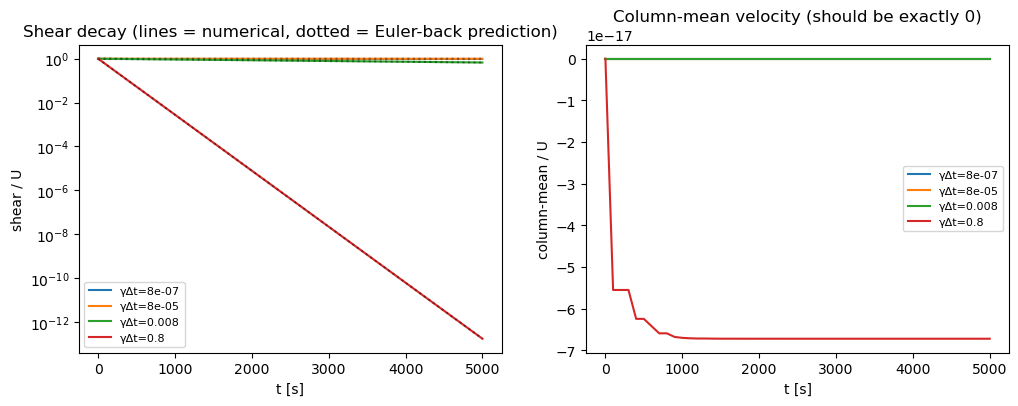

In [9]:
H = 500.0
dt = 100.0
nsteps = 50

fig, (ax_s, ax_m) = plt.subplots(1, 2, figsize=(12, 4))
print(f'{"γΔt":>10s}  {"max|shear-EB|":>16s}  {"max|mean|":>12s}')
for nu_v in [1e-3, 1e-1, 1e1, 1e3]:
    M = SSWEM(1, [0., 0.], [H, H], 1.e6,
              0., 0.,    # no Coriolis
              0.,        # no drag
              0.,        # no lateral viscosity
              nu_v=nu_v)
    M.u[0] = +1.0; M.u[1] = -1.0
    u, v, h, time = M.run(dt, 1, nsteps)
    shear = 0.5 * (u[:, 0, 0, 0] - u[:, 1, 0, 0])
    mean  = 0.5 * (u[:, 0, 0, 0] + u[:, 1, 0, 0])
    gamma = 2 * nu_v / H**2
    shear_eb = (1.0 + gamma * dt) ** -np.arange(len(time))
    ax_s.semilogy(time, np.maximum(shear, 1e-30), '-', label=f'γΔt={gamma*dt:.2g}')
    ax_s.semilogy(time, shear_eb, 'k:', alpha=0.4)
    ax_m.plot(time, mean, label=f'γΔt={gamma*dt:.2g}')
    print(f'{gamma*dt:10.3g}  {np.max(np.abs(shear - shear_eb)):16.2e}  {np.max(np.abs(mean)):12.2e}')

ax_s.set_xlabel('t [s]'); ax_s.set_ylabel('shear / U')
ax_s.set_title('Shear decay (lines = numerical, dotted = Euler-back prediction)')
ax_s.legend(fontsize=8)
ax_m.set_xlabel('t [s]'); ax_m.set_ylabel('column-mean / U')
ax_m.set_title('Column-mean velocity (should be exactly 0)')
ax_m.legend(fontsize=8);

## 9. Two-mode decay with combined drag + vertical viscosity
Equal layers, no Coriolis / gravity / lateral / wind. With both $\varepsilon > 0$ and $\nu_v > 0$ the column has two relaxation modes: the $2\times 2$ matrix
$$ A = \begin{pmatrix} \nu_v / h^2 & -\nu_v / h^2 \\ -\nu_v / h^2 & \nu_v / h^2 + \varepsilon / h \end{pmatrix} $$
has eigenvalues $\lambda_\pm = ((a+b) \pm \sqrt{a^2 + b^2}) / 2$ with $a = 2\nu_v / h^2$ and $b = \varepsilon / h$. Project the numerical trajectory onto these eigenvectors and check each mode decays at the corresponding Euler-backward rate $(1 + \lambda_k \Delta t)^{-n}$.

Three regimes: viscosity-dominated ($a \gg b$, the fast mode is shear decay, the slow mode is column-uniform drag), drag-dominated ($a \ll b$, the fast mode is the bottom layer decaying, the slow mode is the top layer leaking down via $\nu_v$), and balanced.

Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
cg1 = 0.0 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 2e-06
CFL: dt*nu_v/h_min^2 = 4e-05
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 200
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
cg1 = 0.0 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 0.002
CFL: dt*nu_v/h_min^2 = 4.0000000000000003e-07
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 200
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
cg1 = 0.0 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 2e-05
CFL: dt*nu_v/h_min^2 = 4.0000000000000003e-07
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps

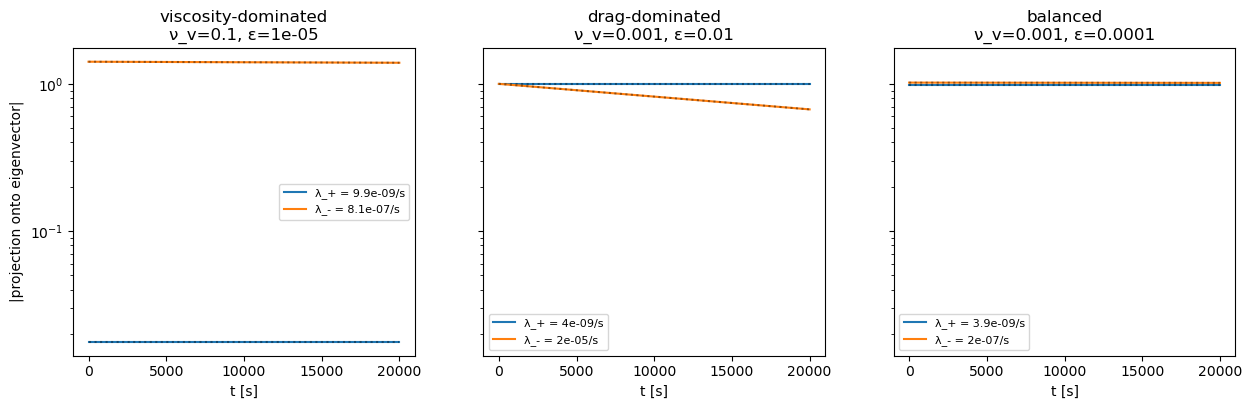

In [10]:
H = 500.0
dt = 100.0
nsteps = 200

cases = [(1e-1, 1e-5, 'viscosity-dominated'),
         (1e-3, 1e-2, 'drag-dominated'),
         (1e-3, 1e-4, 'balanced')]

fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (nu_v, eps, label) in zip(axs, cases):
    M = SSWEM(1, [0., 0.], [H, H], 1.e6, 0., 0., eps, 0., nu_v=nu_v)
    M.u[0] = +1.0; M.u[1] = -1.0
    u, v, h, time = M.run(dt, 1, nsteps)
    u_traj = u[:, :, 0, 0]  # (nsamp+1, 2)
    A = np.array([[nu_v/H**2, -nu_v/H**2],
                  [-nu_v/H**2, nu_v/H**2 + eps/H]])
    evals, evecs = np.linalg.eig(A)
    coords = np.linalg.solve(evecs, u_traj.T).T  # project onto eigenvectors
    for k in range(2):
        eb = coords[0, k] * (1 + evals[k] * dt) ** -np.arange(len(time))
        ax.semilogy(time, np.abs(coords[:, k]),
                    label=f'λ_{["+","-"][k]} = {evals[k]:.2g}/s')
        ax.semilogy(time, np.abs(eb), 'k:', alpha=0.4)
    ax.set_xlabel('t [s]'); ax.set_title(f'{label}\nν_v={nu_v}, ε={eps}')
    ax.legend(fontsize=8)
axs[0].set_ylabel('|projection onto eigenvector|')

# Quantitative agreement check (printed)
print(f'{"case":>20s}  {"max | num - EB | per mode":>30s}')
for (nu_v, eps, label) in cases:
    M = SSWEM(1, [0., 0.], [H, H], 1.e6, 0., 0., eps, 0., nu_v=nu_v)
    M.u[0] = +1.0; M.u[1] = -1.0
    u, _, _, time = M.run(dt, 1, nsteps)
    u_traj = u[:, :, 0, 0]
    A = np.array([[nu_v/H**2, -nu_v/H**2], [-nu_v/H**2, nu_v/H**2 + eps/H]])
    evals, evecs = np.linalg.eig(A)
    coords = np.linalg.solve(evecs, u_traj.T).T
    errs = [np.max(np.abs(coords[:, k] - coords[0, k] * (1 + evals[k] * dt) ** -np.arange(len(time))))
            for k in range(2)]
    print(f'{label:>20s}  {errs[0]:11.2e}  {errs[1]:11.2e}')

## 10. Inertial-shear hodograph
Equal layers, Coriolis only (no gravity / drag / lateral / wind), with $\nu_v > 0$. Initial state: $u_0 = +U$, $u_1 = -U$, $v = 0$. The complex shear $\sigma \equiv (u_0 - u_1) + i\,(v_0 - v_1)$ should satisfy $\partial_t \sigma = -(\gamma + i f)\,\sigma$ with $\gamma = 2\nu_v / h^2$, i.e. a logarithmic spiral that rotates at $f$ and decays at $\gamma$. The column-mean velocity (initially zero, with no friction acting on it) should stay at zero — this is the test that vertical viscosity is **decoupled from the column-mean** and only acts on the shear, and that the Coriolis cross-coupling does not leak into the mean.

In [ ]:
H = 500.0
fo = 1e-4
nu_v = 5e-2
dt = 100.0
nsteps = 1500   # about 2.4 inertial periods

M = SSWEM(1, [0., 0.], [H, H], 1.e6, fo, 0., 0., 0., nu_v=nu_v)
M.u[0] = +1.0; M.u[1] = -1.0
u, v, h, time = M.run(dt, 1, nsteps)
shear_u = u[:, 0, 0, 0] - u[:, 1, 0, 0]
shear_v = v[:, 0, 0, 0] - v[:, 1, 0, 0]
mean_u  = u[:, 0, 0, 0] + u[:, 1, 0, 0]
mean_v  = v[:, 0, 0, 0] + v[:, 1, 0, 0]

# Continuous prediction: σ(t) = σ(0) exp(-(γ + i f) t)
gamma = 2 * nu_v / H**2
sigma_pred_re = 2.0 * np.exp(-gamma * time) * np.cos(fo * time)
sigma_pred_im = -2.0 * np.exp(-gamma * time) * np.sin(fo * time)

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].plot(shear_u, shear_v, 'C0-', label='numerical')
axs[0].plot(sigma_pred_re, sigma_pred_im, 'k:', alpha=0.5, label='continuous')
axs[0].set_aspect('equal'); axs[0].set_xlabel(r'$u_0 - u_1$')
axs[0].set_ylabel(r'$v_0 - v_1$'); axs[0].set_title('Hodograph of shear vector')
axs[0].legend()

axs[1].plot(time, mean_u, label=r'$\overline{u}$')
axs[1].plot(time, mean_v, label=r'$\overline{v}$')
axs[1].set_xlabel('t [s]'); axs[1].set_title('Column-mean velocity (should be 0)')
axs[1].legend()

print(f'γΔt = {gamma * dt:.2e},  fΔt = {fo * dt:.3f}')
print(f'max |mean u| = {np.max(np.abs(mean_u)):.2e}')
print(f'max |mean v| = {np.max(np.abs(mean_v)):.2e}')
print(f'final |shear|: numerical = {np.sqrt(shear_u[-1]**2 + shear_v[-1]**2):.4f}, '
      f'continuous = {2 * np.exp(-gamma * time[-1]):.4f}')

## 11. Ekman-like steady-state column structure
Equal layers, no Coriolis / gravity / lateral viscosity. Constant zonal wind on the top layer, bottom drag $\varepsilon$, vertical viscosity $\nu_v$ coupling them. Setting $\partial_t u_k = 0$ in both layers gives the closed-form steady state
$$ u_1^* = \frac{\tau^x}{\varepsilon}, \qquad u_0^* - u_1^* = \frac{\tau^x\,(h_0 + h_1)}{2\,\nu_v}, $$
so the bottom layer is set by the column-integrated drag balance and the inter-layer shear is set by the interfacial-stress balance. The transient relaxes at the slower of the two eigenvalues from test 9; we choose $(\varepsilon, \nu_v)$ so this completes in $\mathcal{O}(10^4)$ steps and then compare the numerical asymptote to the analytical formula.

     ν_v         u_1 num         u_1 ana         u_0 num         u_0 ana     rel.err
Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
cg1 = 0.0 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 0.1
CFL: dt*nu_v/h_min^2 = 0.01
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 10000
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
      10     1.00000e-02     1.00000e-02     1.10000e-01     1.10000e-01    7.81e-15
Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
cg1 = 0.0 [m s-1]
Ld1 = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/h_bot = 0.1
CFL: dt*nu_v/h_min^2 = 0.001
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*cg1/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 10000
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
       1     9.99949e-03     1.00000e-02     1.00995e+00     1.01000e+00    5.09e-05


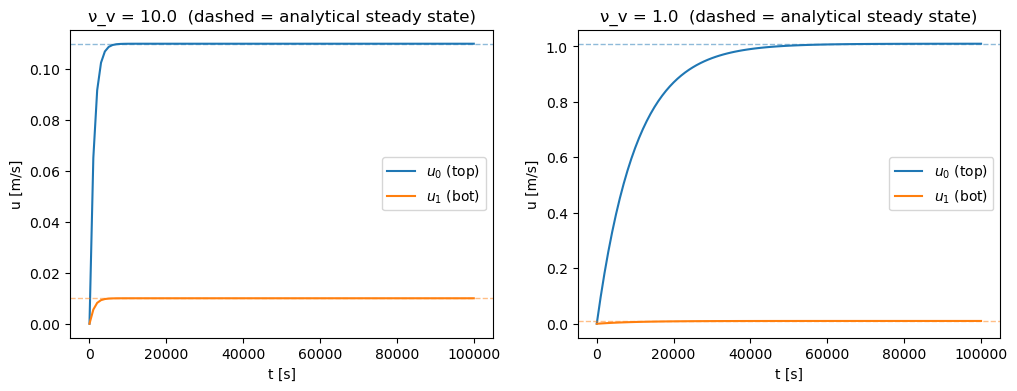

In [12]:
H = 100.0
eps = 1.0
tau_x = 0.01
dt = 10.0
nsteps_total = 10000   # = 1e5 s

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
print(f'{"ν_v":>8s}  {"u_1 num":>14s}  {"u_1 ana":>14s}  {"u_0 num":>14s}  {"u_0 ana":>14s}  {"rel.err":>10s}')
for ax, nu_v in zip(axs, [10.0, 1.0]):
    M = SSWEM(1, [0., 0.], [H, H], 1.e6, 0., 0., eps, 0., nu_v=nu_v)
    M.taux = M.taux * 0. + tau_x   # uniform wind on top layer
    u, v, h, time = M.run(dt, 100, nsteps_total // 100)
    u1_ss = tau_x / eps
    u0_ss = u1_ss + tau_x * H / nu_v   # since (h_0+h_1)/2 = H
    u0_num = float(u[-1, 0, 0, 0]); u1_num = float(u[-1, 1, 0, 0])
    rel = max(abs(u0_num - u0_ss) / abs(u0_ss), abs(u1_num - u1_ss) / abs(u1_ss))
    print(f'{nu_v:8.2g}  {u1_num:14.5e}  {u1_ss:14.5e}  {u0_num:14.5e}  {u0_ss:14.5e}  {rel:10.2e}')
    ax.plot(time, u[:, 0, 0, 0], label=r'$u_0$ (top)')
    ax.plot(time, u[:, 1, 0, 0], label=r'$u_1$ (bot)')
    ax.axhline(u0_ss, color='C0', ls='--', alpha=0.5, lw=1)
    ax.axhline(u1_ss, color='C1', ls='--', alpha=0.5, lw=1)
    ax.set_xlabel('t [s]'); ax.set_ylabel('u [m/s]')
    ax.set_title(f'ν_v = {nu_v}  (dashed = analytical steady state)')
    ax.legend()